# NanoDet-Plus Custom Pipeline + SAHI Integration

This notebook sets up **NanoDet-Plus** for the VisDrone dataset and introduces a **Custom SAHI wrapper** to achieve State-of-the-Art performance on small object detection. Divided clearly into **Phase 1 (Without SAHI)** and **Phase 2 (With SAHI)**.

---
## 1. Setup Environment
Clones the official NanoDet repository, installs dependencies, and prepares the workspace.

In [37]:
!pip uninstall -y pytorch-lightning lightning lightning-fabric
!pip install pytorch-lightning==1.9.5

Found existing installation: pytorch-lightning 1.9.5
Uninstalling pytorch-lightning-1.9.5:
  Successfully uninstalled pytorch-lightning-1.9.5
  Using cached pytorch_lightning-1.9.5-py3-none-any.whl.metadata (23 kB)
Using cached pytorch_lightning-1.9.5-py3-none-any.whl (829 kB)


In [ ]:
import os
os._exit(0)

In [1]:
%cd /kaggle/working
!rm -rf nanodet
!git clone https://github.com/RangiLyu/nanodet.git
%cd /kaggle/working/nanodet
!pip install -r requirements.txt
!pip install addict pycocotools sahi tqdm pillow pyyaml
!python setup.py develop

/kaggle/working
Cloning into 'nanodet'...
remote: Enumerating objects: 2722, done.
remote: Total 2722 (delta 0), reused 0 (delta 0), pack-reused 2722 (from 1)
Receiving objects: 100% (2722/2722), 5.29 MiB | 21.50 MiB/s, done.
Resolving deltas: 100% (1601/1601), done.
/kaggle/working/nanodet
  Using cached onnx_simplifier-0.5.0.tar.gz (728 bytes)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Could not find a version that satisfies the requirement torch<2.0,>=1.10 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0, 2.12.0)
ERROR: No matching distribution found for torch<2.0,>=1.10
running develop
/usr/local/lib/python3.12/dist-packages/setuptools/command/develop.py:41: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ****************************************************************

---
## 2. Link Dataset
Creates a direct symbolic link to your Kaggle input dataset. Make sure `DATASET_PATH` perfectly matches your uploaded dataset folder structure.

In [2]:
import os

print("Available datasets in Kaggle input:")
print(os.listdir('/kaggle/input'))

# !!! IMPORTANT !!!
# Change to the EXACT name of the folder inside /kaggle/input/
DATASET_PATH = '/kaggle/input/datasets/yasirarafatdiptaw/visdrone-coco-dataset/VisDrone-DET'

!ln -s {DATASET_PATH} /kaggle/working/VisDrone-DET

Available datasets in Kaggle input:
['datasets']
ln: failed to create symbolic link '/kaggle/working/VisDrone-DET/VisDrone-DET': Read-only file system


---
## 3. Generate NanoDet Config
Dynamically generates the `nanodet-plus-m_visdrone.yml` configuration file based on available GPUs and dataset paths. It includes the required `aux_head` for the Plus version.

In [3]:
import yaml
import os
import torch

n_gpu = torch.cuda.device_count() if torch.cuda.is_available() else 0
gpu_ids_list = list(range(n_gpu)) if n_gpu > 0 else [0]
WORKING_ROOT = '/kaggle/working/VisDrone-DET'

config_text = f"""save_dir: workspace/nanodet_visdrone_m
model:
  weight_averager:
    name: ExpMovingAverager
    decay: 0.9998
  arch:
    name: NanoDetPlus
    detach_epoch: 10
    backbone:
      name: ShuffleNetV2
      model_size: 1.0x
      out_stages: [2,3,4]
      activation: LeakyReLU
    fpn:
      name: GhostPAN
      in_channels: [116, 232, 464]
      out_channels: 96
      kernel_size: 5
      num_extra_level: 1
      use_depthwise: True
      activation: LeakyReLU
    head:
      name: NanoDetPlusHead
      num_classes: 10
      input_channel: 96
      feat_channels: 96
      stacked_convs: 2
      kernel_size: 5
      strides: [8, 16, 32, 64]
      activation: LeakyReLU
      reg_max: 7
      norm_cfg:
        type: BN
      loss:
        loss_qfl:
          name: QualityFocalLoss
          use_sigmoid: True
          beta: 2.0
          loss_weight: 1.0
        loss_dfl:
          name: DistributionFocalLoss
          loss_weight: 0.25
        loss_bbox:
          name: GIoULoss
          loss_weight: 2.0
    aux_head:
      name: SimpleConvHead
      num_classes: 10
      input_channel: 192
      feat_channels: 192
      stacked_convs: 4
      strides: [8, 16, 32, 64]
      activation: LeakyReLU
      reg_max: 7
class_names: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
data:
  train:
    name: CocoDataset
    img_path: {WORKING_ROOT}/images/train
    ann_path: {WORKING_ROOT}/coco_annotations/instances_train.json
    input_size: [640,640]
    keep_ratio: True
    pipeline:
      perspective: 0.0
      scale: [0.6, 1.4]
      stretch: [[0.8, 1.2], [0.8, 1.2]]
      rotation: 0
      shear: 0
      translate: 0.2
      flip: 0.5
      brightness: 0.2
      contrast: [0.6, 1.4]
      saturation: [0.5, 1.2]
      normalize: [[103.53, 116.28, 123.675], [57.375, 57.12, 58.395]]
  val:
    name: CocoDataset
    img_path: {WORKING_ROOT}/images/val
    ann_path: {WORKING_ROOT}/coco_annotations/instances_val.json
    input_size: [640,640]
    keep_ratio: True
    pipeline:
      normalize: [[103.53, 116.28, 123.675], [57.375, 57.12, 58.395]]
device:
  gpu_ids: {gpu_ids_list}
  workers_per_gpu: 4
  batchsize_per_gpu: 16
schedule:
  val_intervals: 10
  optimizer:
    name: AdamW
    lr: 0.001
    weight_decay: 0.05
  warmup:
    name: linear
    steps: 500
    ratio: 0.0001
  lr_schedule:
    name: MultiStepLR
    milestones: [40, 45, 48]
    gamma: 0.1
  total_epochs: 50
evaluator:
  name: CocoDetectionEvaluator
  save_key: mAP
"""
os.makedirs('/kaggle/working/nanodet/config', exist_ok=True)
CONF_FILE = '/kaggle/working/nanodet/config/nanodet-plus-m_visdrone.yml'
with open(CONF_FILE, 'w') as f:
    f.write(config_text)
print('Wrote NanoDet Plus config.')

Wrote NanoDet Plus config.


---
## 4. PyTorch 2.x & Checkpoint Bug Patches
NanoDet uses `torch._six` which is deprecated in PyTorch 2.x. It also has a bug when loading empty checkpoints (`load_model=None`). This cell fixes both issues directly in the source code.

In [4]:
import os

print('Applying NanoDet PyTorch 2.x and load_model patches...')

nanodet_root = '/kaggle/working/nanodet'
for root, dirs, files in os.walk(nanodet_root):
    for fname in files:
        if not fname.endswith('.py'):
            continue
        fpath = os.path.join(root, fname)
        with open(fpath, 'r', errors='ignore') as f:
            content = f.read()
        if 'torch._six' in content:
            content = content.replace('from torch._six import string_classes', 'string_classes = str')
            content = content.replace('from torch._six import int_classes', 'int_classes = int')
            content = content.replace('from torch._six import container_abcs', 'import collections.abc as container_abcs')
            with open(fpath, 'w') as f:
                f.write(content)

# Fix logic bugs in train.py by making sure it checks if the value is truthy, not just "in cfg"
train_py = os.path.join(nanodet_root, 'tools', 'train.py')
with open(train_py, 'r') as f:
    content = f.read()
    
content = content.replace('if "load_model" in cfg.schedule:', 'if "load_model" in cfg.schedule and cfg.schedule.load_model:')
content = content.replace('if "resume" in cfg.schedule', 'if "resume" in cfg.schedule and cfg.schedule.resume')

content = content.replace('strategy=strategy,', 'strategy=strategy if strategy is not None else "auto",')

with open(train_py, 'w') as f:
    f.write(content)

print('Patches Applied Successfully!')

Applying NanoDet PyTorch 2.x and load_model patches...
Patches Applied Successfully!


---
## 5. Train & Auto-Resume Checkpoints
Auto-discovers existing checkpoints from Kaggle datasets or session outputs. If found, it automatically injects them into the configuration to resume training. Otherwise, it starts fresh.

In [ ]:
import os, shutil
import yaml

# ── Configuration ─────────────────────────────────────────────────────────────
OUTPUT_DIR           = '/kaggle/working/nanodet/workspace/nanodet_visdrone_m'
BACKUP_DIR           = '/kaggle/working/checkpoints'   # backed up to session output
KAGGLE_INPUT_CKPT_DIR = '/kaggle/input/nanodet-checkpoints'   # <── change if needed

LAST_CKPT = os.path.join(OUTPUT_DIR, 'model_last.ckpt')
BEST_CKPT = os.path.join(OUTPUT_DIR, 'model_best.ckpt')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(BACKUP_DIR, exist_ok=True)

# ── Checkpoint restore helper ─────────────────────────────────────────────────
def restore_checkpoint(src_dir, label):
    restored = False
    for fname, dst in [('model_last.ckpt', LAST_CKPT), ('model_best.ckpt', BEST_CKPT)]:
        import glob
        matches = glob.glob(f'{src_dir}/**/{fname}', recursive=True)
        if matches and not os.path.exists(dst):
            shutil.copy2(matches[0], dst)
            size_mb = os.path.getsize(dst) / 1024 / 1024
            print(f'[Checkpoint] Restored {fname} from {label}  ({size_mb:.1f} MB)')
            restored = True
    return restored

if os.path.exists(LAST_CKPT):
    print(f'[Checkpoint] Found checkpoint in output dir: {LAST_CKPT}')
elif restore_checkpoint(BACKUP_DIR, 'session backup'):
    pass
elif restore_checkpoint(KAGGLE_INPUT_CKPT_DIR, 'Kaggle input dataset'):
    pass
else:
    print('[Checkpoint] No checkpoint found – training will start from scratch.')

# ── Update Config for Resume ─────────────────────────────────────────────────
%cd /kaggle/working/nanodet
CONF_FILE = 'config/nanodet-plus-m_visdrone.yml'
with open(CONF_FILE, 'r') as f:
    cfg = yaml.safe_load(f)

if os.path.exists(LAST_CKPT):
    cfg['schedule']['resume'] = LAST_CKPT
    print(f'[Checkpoint] ▶ Resuming training from: {LAST_CKPT}')
else:
    if 'resume' in cfg['schedule']:
        del cfg['schedule']['resume']
    if 'load_model' in cfg['schedule']:
        del cfg['schedule']['load_model']
    print('[Checkpoint] ▶ Starting fresh training run.')

with open(CONF_FILE, 'w') as f:
    yaml.dump(cfg, f)

# ── Build and run training command ───────────────────────────────────────────
cmd = f'python tools/train.py {CONF_FILE}'
print(f'[Command] Running: {cmd}\n')
os.system(cmd)

---
## 6. Backup Checkpoints for Next Session
Copies the checkpoints to a dedicated backup directory so they persist at the end of your Kaggle session.

In [10]:
import os, shutil
import glob

BACKUP_DIR = '/kaggle/working/checkpoints'
os.makedirs(BACKUP_DIR, exist_ok=True)

print("Searching everywhere in /kaggle/working/ for any .ckpt or .pth files...")
all_ckpts = glob.glob('/kaggle/working/**/*.ckpt', recursive=True) + glob.glob('/kaggle/working/**/*.pth', recursive=True)

# Filter out the backup dir itself so we don't copy already backed-up files
all_ckpts = [f for f in all_ckpts if '/checkpoints/' not in f]

backed_up = []
for src in all_ckpts:
    fname = os.path.basename(src)
    dst = os.path.join(BACKUP_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / 1024 / 1024
        print(f'[Backup] Found {fname} at {src}  →  Backed up ({size_mb:.1f} MB)')
        backed_up.append(fname)

if backed_up:
    print(f'\n✅ Backed up {len(backed_up)} checkpoint(s)!')
else:
    print('\n⚠️ No checkpoints found! If training finished and no checkpoints exist, it means the PyTorch Lightning 2.x save bug prevented saving. Please ensure Cell 4 (Patches) was run before Cell 5!')


Searching everywhere in /kaggle/working/ for any .ckpt or .pth files...
[Backup] Found model_last.ckpt at /kaggle/working/nanodet/workspace/nanodet_visdrone_m/model_last.ckpt  →  Backed up (65.1 MB)

✅ Backed up 1 checkpoint(s)!


In [25]:
%cd /kaggle/working/nanodet

from pathlib import Path

p = Path("tools/test.py")
txt = p.read_text()

txt = txt.replace(
"""    if cfg.device.gpu_ids == -1:
        logger.info("Using CPU training")
        accelerator, devices = "cpu", None
    else:
        accelerator, devices = "gpu", cfg.device.gpu_ids
""",
"""    logger.info("Force single GPU testing")
    accelerator = "gpu"
    devices = 1
"""
)

txt = txt.replace(
"""    trainer = pl.Trainer(
        default_root_dir=cfg.save_dir,
        accelerator=accelerator,
        devices=devices,
        log_every_n_steps=cfg.log.interval,
        num_sanity_val_steps=0,
        logger=logger,
    )
""",
"""    trainer = pl.Trainer(
        default_root_dir=cfg.save_dir,
        accelerator="gpu",
        devices=1,
        strategy="auto",
        log_every_n_steps=cfg.log.interval,
        num_sanity_val_steps=0,
        logger=logger,
    )
"""
)

p.write_text(txt)

print("✅ test.py patched")

/kaggle/working/nanodet
✅ test.py patched


In [26]:
%cd /kaggle/working/nanodet

import yaml
import glob

CONF_FILE = "config/nanodet-plus-m_visdrone.yml"

with open(CONF_FILE, "r") as f:
    cfg = yaml.safe_load(f)

cfg["data"]["val"]["img_path"] = "/kaggle/working/VisDrone-DET/images/test-dev"
cfg["data"]["val"]["ann_path"] = "/kaggle/working/VisDrone-DET/coco_annotations/instances_test-dev.json"

cfg["device"]["gpu_ids"] = [0]

TEST_CONF = "config/nanodet-plus-m_visdrone_test.yml"

with open(TEST_CONF, "w") as f:
    yaml.dump(cfg, f)

weights = (
    glob.glob("/kaggle/working/nanodet/workspace/nanodet_visdrone_m/model_best*.ckpt")
    + glob.glob("/kaggle/working/nanodet/workspace/nanodet_visdrone_m/model_last*.ckpt")
)

BEST_CKPT = weights[0]

print("="*60)
print("PHASE 1 : EVALUATION")
print("="*60)
print("Using:", BEST_CKPT)

!python tools/test.py --config {TEST_CONF} --model {BEST_CKPT}

/kaggle/working/nanodet
PHASE 1 : EVALUATION
Using: /kaggle/working/nanodet/workspace/nanodet_visdrone_m/model_last.ckpt
[NanoDet][06-13 15:11:00]INFO:Setting up data...
loading annotations into memory...
Done (t=0.29s)
creating index...
index created!
[NanoDet][06-13 15:11:01]INFO:Creating model...
model size is  1.0x
init weights...
=> loading pretrained model https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth
Finish initialize NanoDet-Plus Head.
[NanoDet][06-13 15:11:02]INFO:Force single GPU testing
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
[NanoDet][06-13 15:11:02]INFO:Starting testing...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, test_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing th

---
# 7. Phase 1: Baseline Evaluation & Inference (Without SAHI)
Evaluates NanoDet-Plus out-of-the-box on the full-sized `test-dev` images.

/kaggle/working/nanodet
 PHASE 1 : VISUAL TEST (WITHOUT SAHI)
 Using: /kaggle/working/nanodet/workspace/nanodet_visdrone_m/model_last.ckpt
model size is  1.0x
init weights...
=> loading pretrained model https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth
Finish initialize NanoDet-Plus Head.

 FIRST 3 TEST IMAGES

Processing 0000006_00159_d_0000001.jpg ...
forward time: 0.016s | decode time: 0.006s | 
Class distribution:
  car -> 20
  van -> 1
  truck -> 6

✅ Saved phase1_demo/phase1_result_1.jpg (27 objects)


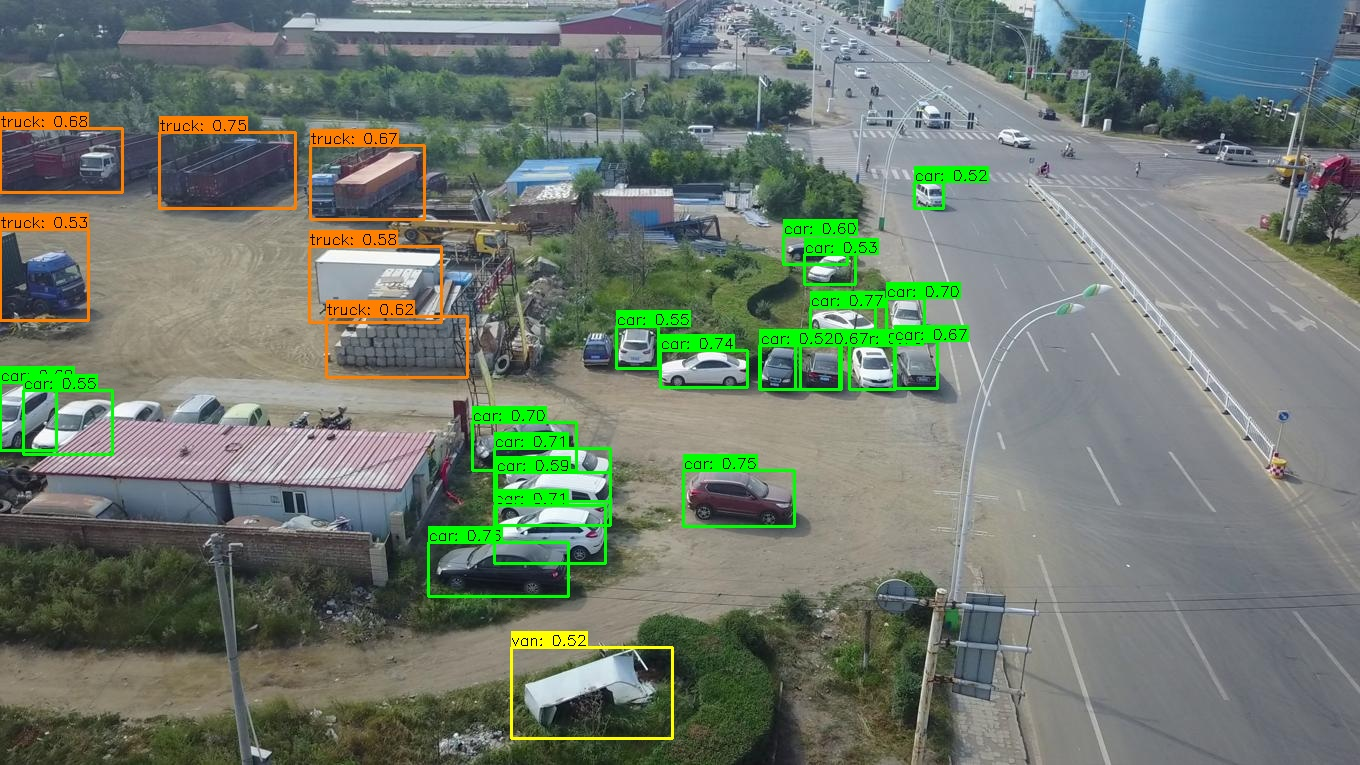


Processing 0000006_00611_d_0000002.jpg ...
forward time: 0.014s | decode time: 0.005s | 
Class distribution:
  car -> 17
  van -> 1
  truck -> 3

✅ Saved phase1_demo/phase1_result_2.jpg (21 objects)


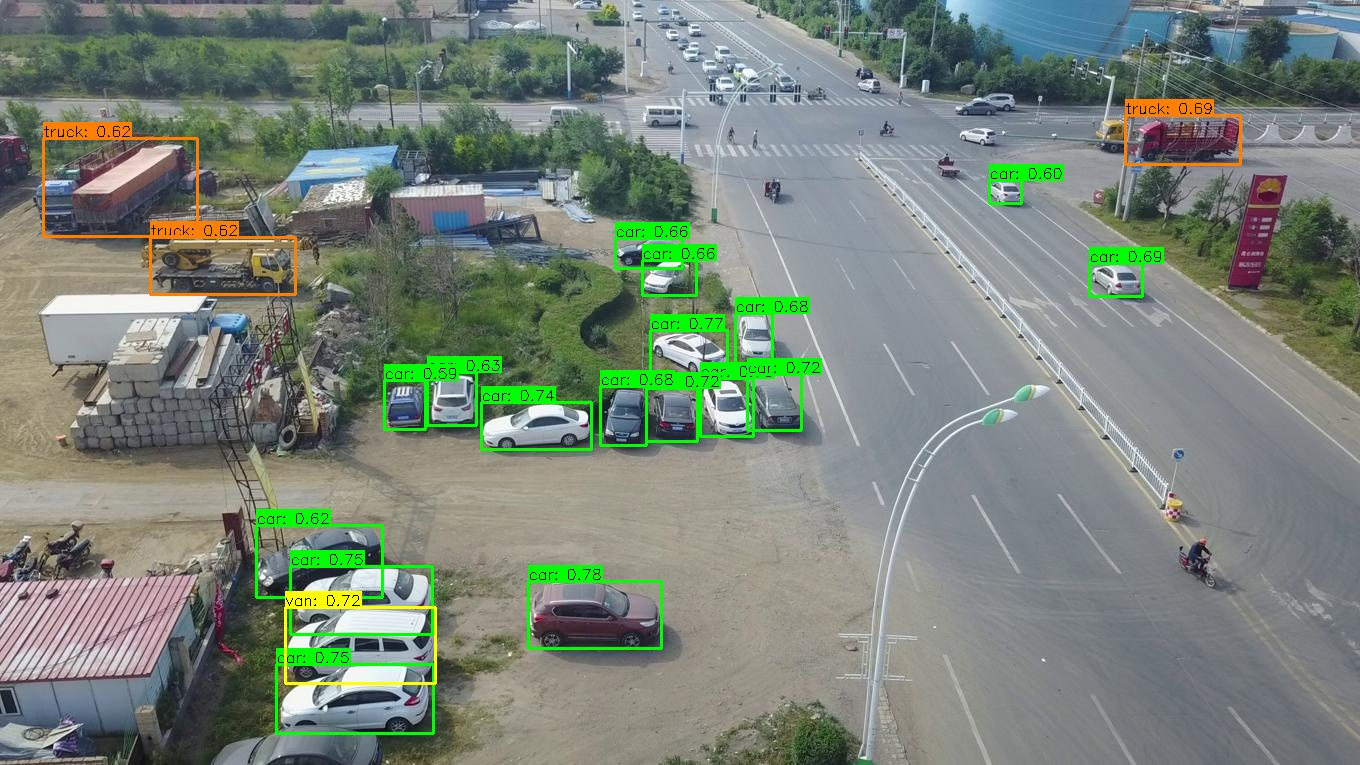


Processing 0000006_01111_d_0000003.jpg ...
forward time: 0.013s | decode time: 0.005s | 
Class distribution:
  car -> 13
  truck -> 2

✅ Saved phase1_demo/phase1_result_3.jpg (15 objects)


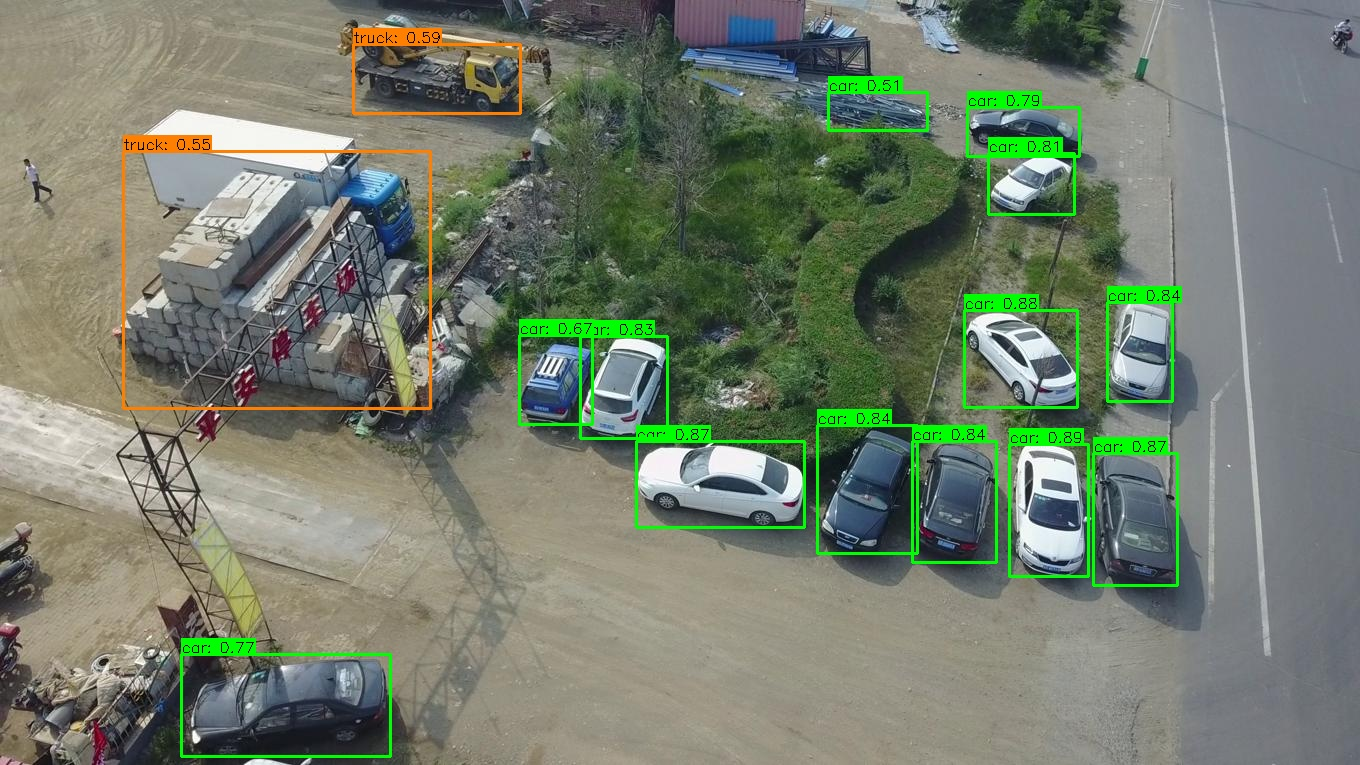

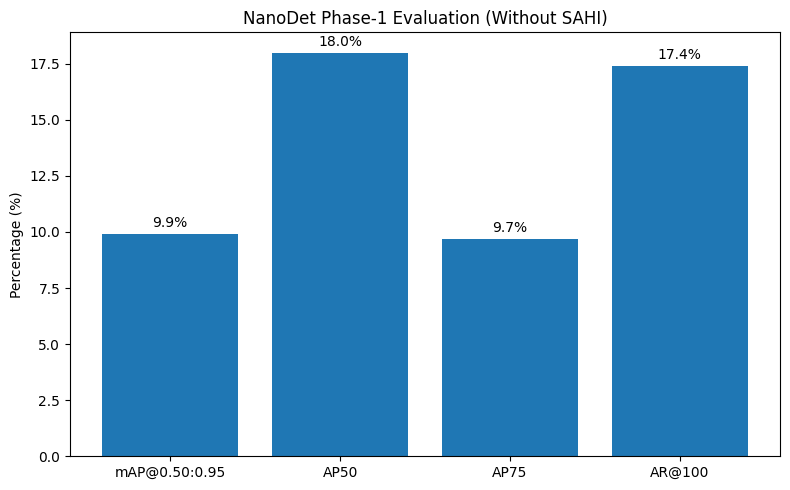


📊 Graph saved: phase1_demo/phase1_metrics.png


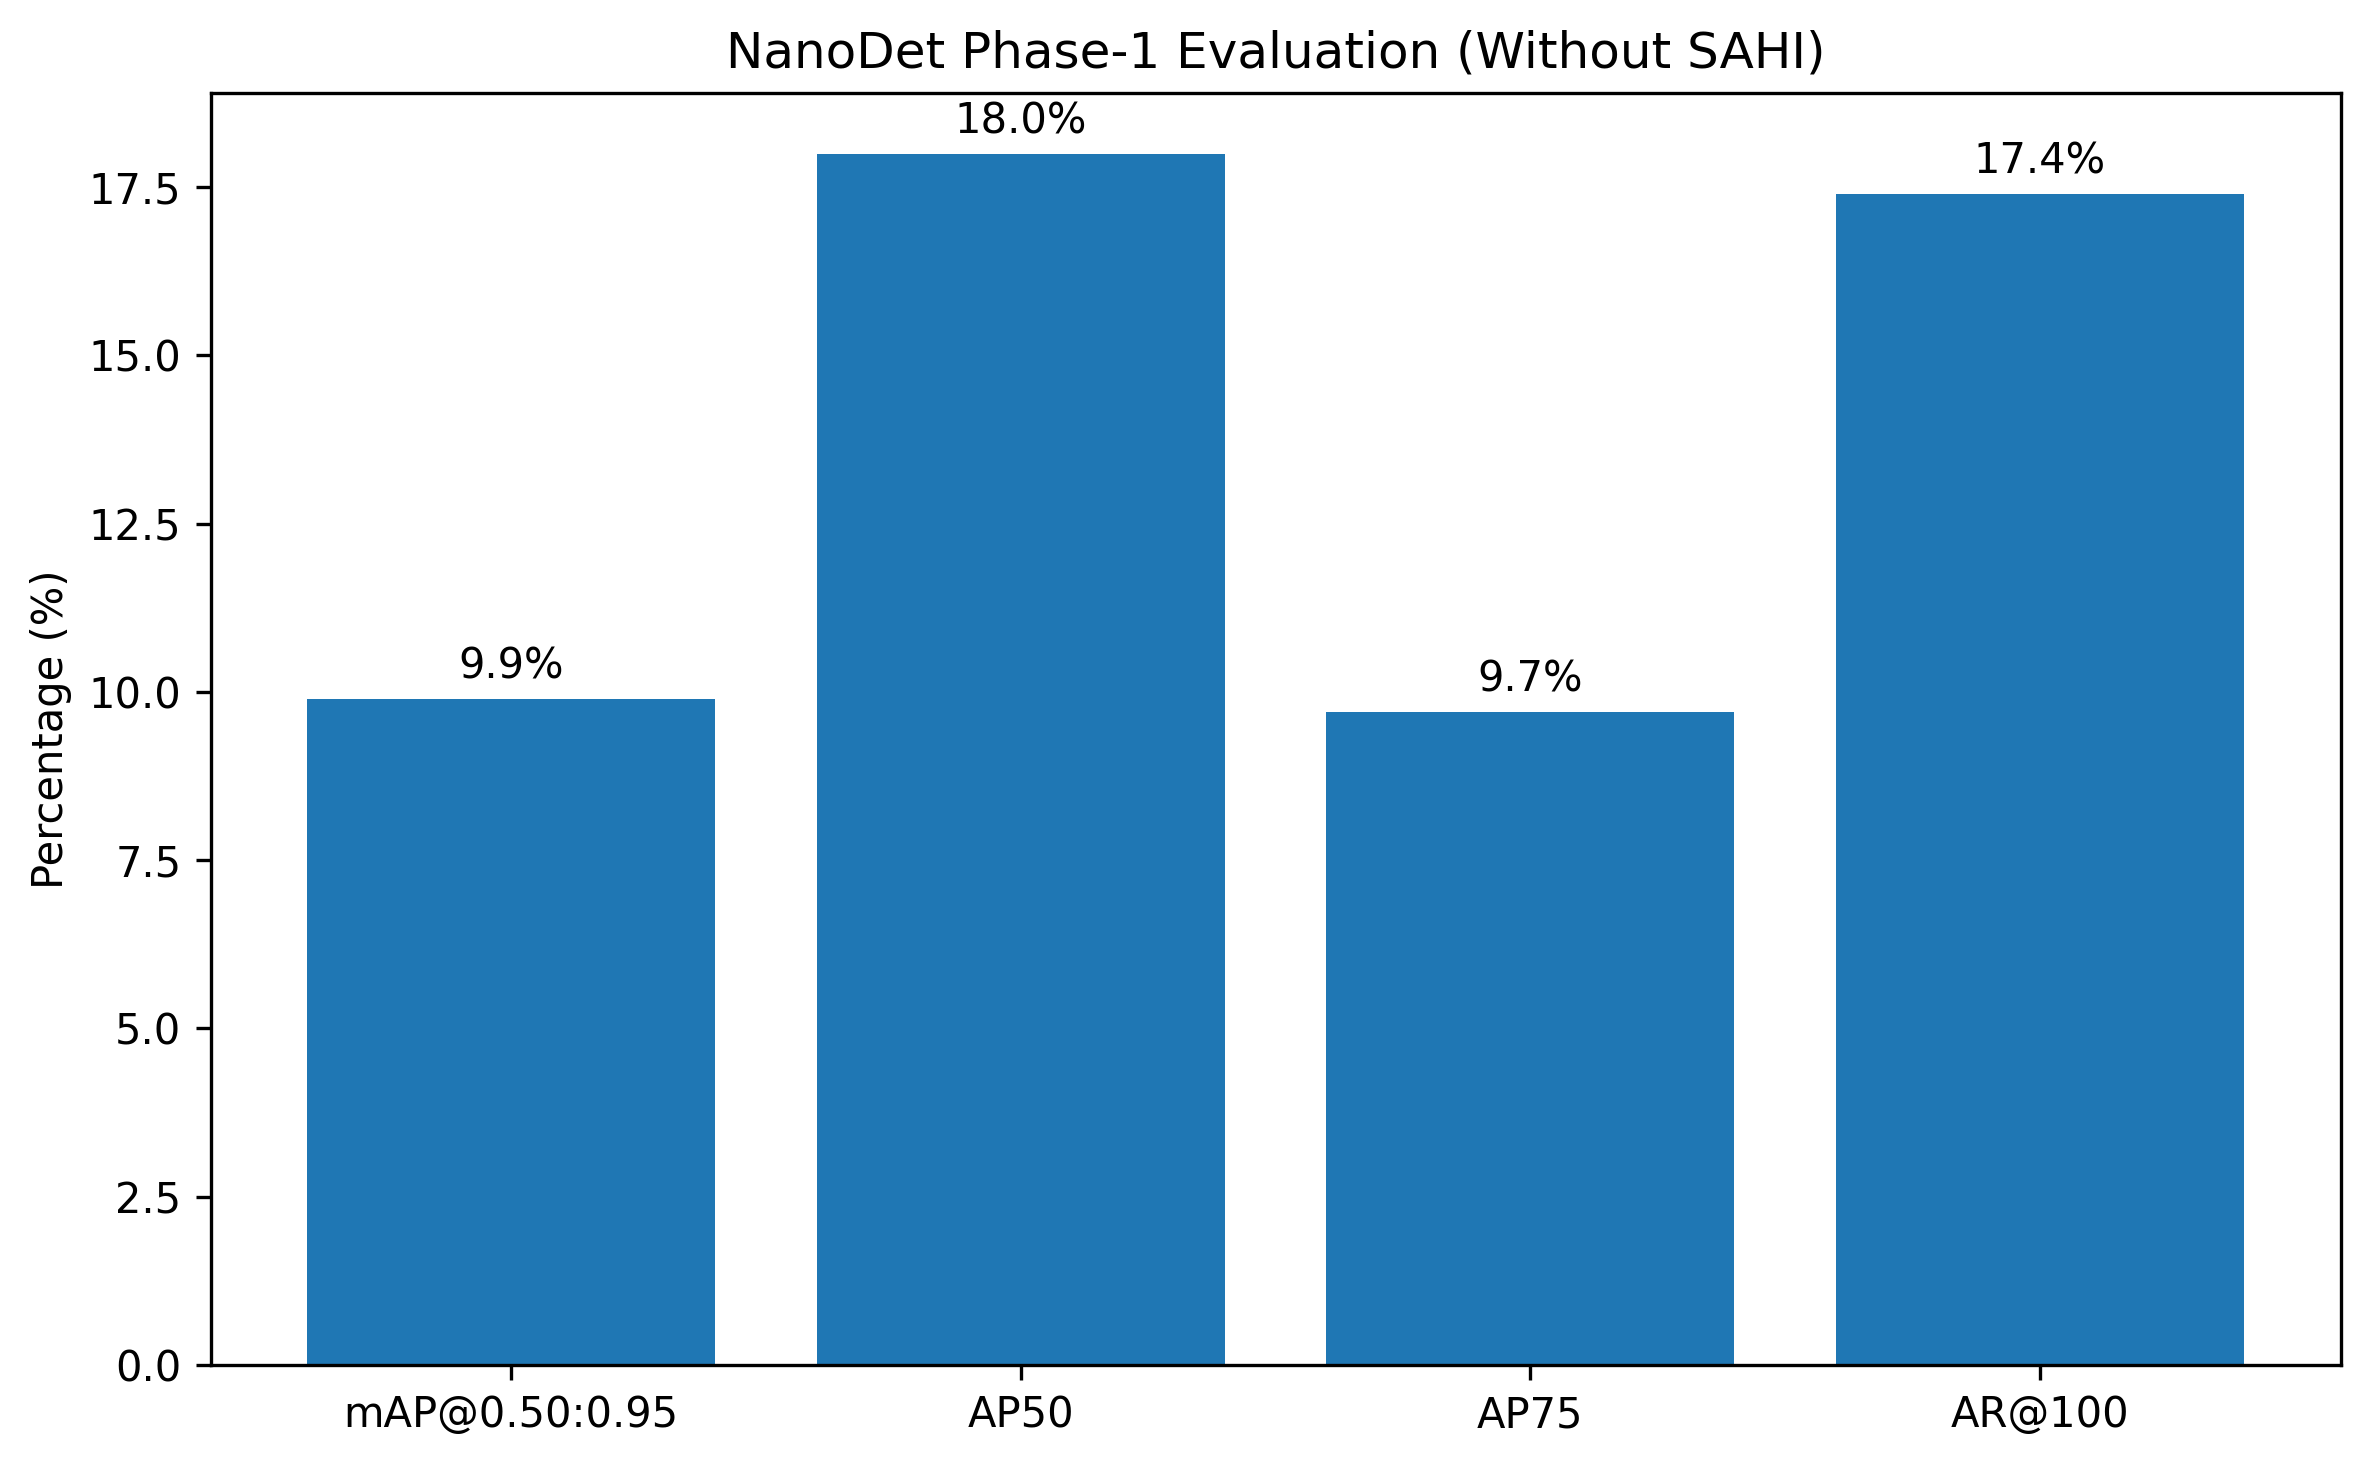


✅ Phase 1 Complete.


In [28]:
%cd /kaggle/working/nanodet

import yaml
import os
import glob
import cv2
import numpy as np
import torch

from collections import Counter
from IPython.display import Image, display

# ============================================================
# CONFIG
# ============================================================

CONF_FILE = "config/nanodet-plus-m_visdrone.yml"

with open(CONF_FILE, "r") as f:
    cfg = yaml.safe_load(f)

cfg["data"]["val"]["img_path"] = "/kaggle/working/VisDrone-DET/images/test-dev"
cfg["data"]["val"]["ann_path"] = "/kaggle/working/VisDrone-DET/coco_annotations/instances_test-dev.json"

cfg["device"]["gpu_ids"] = [0]

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

TEST_CONF = "config/nanodet-plus-m_visdrone_test.yml"

with open(TEST_CONF, "w") as f:
    yaml.dump(cfg, f)

# ============================================================
# CHECKPOINT
# ============================================================

weights = (
    glob.glob("/kaggle/working/nanodet/workspace/nanodet_visdrone_m/model_best*.ckpt")
    + glob.glob("/kaggle/working/nanodet/workspace/nanodet_visdrone_m/model_last*.ckpt")
)

if not weights:
    print("❌ No checkpoint found!")

else:

    BEST_CKPT = weights[0]

    print("=" * 70)
    print(" PHASE 1 : VISUAL TEST (WITHOUT SAHI)")
    print(f" Using: {BEST_CKPT}")
    print("=" * 70)

    # ========================================================
    # IMPORT NANODET
    # ========================================================

    from nanodet.util import cfg as nanodet_cfg
    from nanodet.util import load_config
    from nanodet.util import load_model_weight

    from nanodet.model.arch import build_model
    from nanodet.data.transform import Pipeline

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    load_config(nanodet_cfg, TEST_CONF)

    model = build_model(nanodet_cfg.model)

    ckpt = torch.load(
        BEST_CKPT,
        map_location=device
    )

    load_model_weight(model, ckpt, None)

    model.to(device).eval()

    pipeline = Pipeline(
        nanodet_cfg.data.val.pipeline,
        keep_ratio=nanodet_cfg.data.val.keep_ratio
    )

    input_size = tuple(
        nanodet_cfg.data.val.input_size
    )

    # ========================================================
    # CLASS COLORS
    # ========================================================

    CLASS_COLORS = {
        "pedestrian": (255, 0, 0),
        "people": (255, 128, 0),
        "bicycle": (255, 255, 0),
        "car": (0, 255, 0),
        "van": (0, 255, 255),
        "truck": (0, 128, 255),
        "tricycle": (255, 0, 255),
        "awning-tricycle": (128, 0, 255),
        "bus": (0, 0, 255),
        "motor": (128, 255, 128),
    }

    # ========================================================
    # DETECTION FUNCTION
    # ========================================================

    def nano_detect(image_path):

        img = cv2.imread(image_path)

        h, w = img.shape[:2]

        scale = min(
            input_size[0] / h,
            input_size[1] / w
        )

        new_h = int(round(h * scale))
        new_w = int(round(w * scale))

        resized = cv2.resize(
            img,
            (new_w, new_h)
        )

        pad_h = input_size[0] - new_h
        pad_w = input_size[1] - new_w

        top = pad_h // 2
        bottom = pad_h - top

        left = pad_w // 2
        right = pad_w - left

        padded = cv2.copyMakeBorder(
            resized,
            top,
            bottom,
            left,
            right,
            cv2.BORDER_CONSTANT,
            value=(0, 0, 0)
        )

        meta = dict(
            img_info=dict(
                id=0,
                file_name="",
                height=input_size[0],
                width=input_size[1]
            ),
            raw_img=img.copy(),
            img=padded
        )

        meta = pipeline(
            None,
            meta,
            input_size
        )

        meta["img"] = (
            torch.from_numpy(
                meta["img"].transpose(2, 0, 1)
            )
            .unsqueeze(0)
            .float()
            .to(device)
        )

        if "warp_matrix" in meta:
            meta["warp_matrix"] = [meta["warp_matrix"]]

        meta["img_info"] = {
            k: [v]
            for k, v in meta["img_info"].items()
        }

        with torch.no_grad():
            preds = model.inference(meta)

        if isinstance(preds, list):
            preds = preds[0]

        if isinstance(preds, dict):
            k0 = next(iter(preds))

            if isinstance(preds[k0], dict):
                preds = preds[k0]

        detections = []

        for cls_id, dets in preds.items():

            if isinstance(dets, torch.Tensor):
                dets = dets.cpu().tolist()

            elif isinstance(dets, np.ndarray):
                dets = dets.tolist()

            if not isinstance(dets, list):
                continue

            for det in dets:

                if len(det) < 5:
                    continue

                x1, y1, x2, y2, score = det[:5]

                x1 = (x1 - left) / scale
                y1 = (y1 - top) / scale
                x2 = (x2 - left) / scale
                y2 = (y2 - top) / scale

                x1 = max(0, min(w, x1))
                y1 = max(0, min(h, y1))
                x2 = max(0, min(w, x2))
                y2 = max(0, min(h, y2))

                # HIGHER CONFIDENCE THRESHOLD
                if score < 0.50:
                    continue

                detections.append(
                    [
                        x1,
                        y1,
                        x2,
                        y2,
                        score,
                        int(cls_id)
                    ]
                )

        return detections, img

    # ========================================================
    # VISUALIZE FIRST 3 TEST IMAGES
    # ========================================================

    test_images = sorted(
        os.listdir(
            "/kaggle/working/VisDrone-DET/images/test-dev"
        )
    )[:3]

    os.makedirs(
        "phase1_demo",
        exist_ok=True
    )

    print("\n" + "=" * 70)
    print(" FIRST 3 TEST IMAGES")
    print("=" * 70)

    for idx, img_name in enumerate(test_images, 1):

        img_path = (
            f"/kaggle/working/VisDrone-DET/images/test-dev/{img_name}"
        )

        print(f"\nProcessing {img_name} ...")

        boxes, img = nano_detect(img_path)

        cnt = Counter([b[5] for b in boxes])

        print("\nClass distribution:")

        for cls_id, n in cnt.items():
            print(
                f"  {nanodet_cfg.class_names[cls_id]} -> {n}"
            )

        draw_img = img.copy()

        for box in boxes:

            x1, y1, x2, y2, score, cls = box

            cls_name = nanodet_cfg.class_names[cls]

            color = CLASS_COLORS.get(
                cls_name,
                (0, 255, 0)
            )

            label = (
                f"{cls_name}: {score:.2f}"
            )

            cv2.rectangle(
                draw_img,
                (int(x1), int(y1)),
                (int(x2), int(y2)),
                color,
                2
            )

            (tw, th), _ = cv2.getTextSize(
                label,
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                1
            )

            cv2.rectangle(
                draw_img,
                (int(x1), int(y1) - th - 4),
                (int(x1) + tw, int(y1)),
                color,
                -1
            )

            cv2.putText(
                draw_img,
                label,
                (int(x1), int(y1) - 2),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 0, 0),
                1
            )

        out_path = (
            f"phase1_demo/phase1_result_{idx}.jpg"
        )

        cv2.imwrite(
            out_path,
            draw_img
        )

        print(
            f"\n✅ Saved {out_path} "
            f"({len(boxes)} objects)"
        )

        display(
            Image(filename=out_path)
        )
# ============================================================
# PHASE 1 METRICS GRAPH
# ============================================================

import matplotlib.pyplot as plt

metrics = [
    "mAP@0.50:0.95",
    "AP50",
    "AP75",
    "AR@100"
]

values = [
    9.9,
    18.0,
    9.7,
    17.4
]

plt.figure(figsize=(8, 5))

bars = plt.bar(metrics, values)

plt.ylabel("Percentage (%)")
plt.title("NanoDet Phase-1 Evaluation (Without SAHI)")

for bar, val in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.3,
        f"{val:.1f}%",
        ha="center"
    )

plt.tight_layout()

graph_path = "phase1_demo/phase1_metrics.png"

plt.savefig(
    graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\n📊 Graph saved: {graph_path}")

display(Image(filename=graph_path))
print("\n✅ Phase 1 Complete.")

---
# 8. Custom SAHI Wrapper for NanoDet-Plus
Because NanoDet is not natively supported by the `sahi` library, we build a custom `DetectionModel` class that dynamically translates SAHI's slicing logic into NanoDet's internal inference pipeline.

In [3]:
import numpy as np
import torch
import sys

# Ensure NanoDet modules are available
sys.path.append('/kaggle/working/nanodet')

from sahi.models.base import DetectionModel
from sahi.prediction import ObjectPrediction

from nanodet.util import cfg, load_config, load_model_weight
from nanodet.model.arch import build_model
from nanodet.data.transform import Pipeline


class NanoDetSahi(DetectionModel):

    def load_model(self):
        """Load NanoDet model"""

        load_config(cfg, self.config_path)

        self.cfg = cfg

        self.model = build_model(cfg.model)

        # Load checkpoint
        ckpt = torch.load(
            self.model_path,
            map_location="cpu"
        )

        # NanoDet expects full checkpoint
        load_model_weight(
            self.model,
            ckpt,
            None
        )

        self.model = self.model.to(self.device)
        self.model.eval()

        self.pipeline = Pipeline(
            cfg.data.val.pipeline,
            keep_ratio=cfg.data.val.keep_ratio
        )

        self.input_size = tuple(
            cfg.data.val.input_size
        )

        self.class_names = cfg.class_names

    def perform_inference(self, image: np.ndarray):
        """Run NanoDet on one image/slice"""

        # SAHI gives RGB
        # NanoDet expects BGR
        img_bgr = image[:, :, ::-1].copy()

        height, width = img_bgr.shape[:2]

        img_info = {
            "id": 0,
            "file_name": "",
            "height": height,
            "width": width,
        }

        meta = dict(
            img_info=img_info,
            raw_img=img_bgr,
            img=img_bgr
        )

        meta = self.pipeline(
            None,
            meta,
            self.input_size
        )

        meta["img"] = (
            torch.from_numpy(
                meta["img"].transpose(2, 0, 1)
            )
            .unsqueeze(0)
            .float()
            .to(self.device)
        )

        if "warp_matrix" in meta:
            meta["warp_matrix"] = [meta["warp_matrix"]]

        meta["img_info"] = {
            k: [v]
            for k, v in meta["img_info"].items()
        }

        with torch.no_grad():
            preds = self.model.inference(meta)

        self._original_predictions = preds

    def _create_object_prediction_list_from_original_predictions(
        self,
        shift_amount_list,
        full_shape_list,
    ):
        """Convert NanoDet output to SAHI predictions"""

        shift_y, shift_x = shift_amount_list[0]
        full_shape = full_shape_list[0]

        preds = self._original_predictions

        if isinstance(preds, list):
            preds = preds[0]

        if isinstance(preds, dict):
            k0 = next(iter(preds))
            if isinstance(preds[k0], dict):
                preds = preds[k0]

        object_prediction_list = []

        for class_id, bboxes in preds.items():

            for bbox in bboxes:

                x1, y1, x2, y2, score = bbox[:5]

                score = float(score)

                if score < self.confidence_threshold:
                    continue

                object_prediction = ObjectPrediction(
                    bbox=[x1, y1, x2, y2],
                    category_id=int(class_id),
                    category_name=self.class_names[int(class_id)],
                    score=score,
                    bool_mask=None,
                    shift_amount=[shift_x, shift_y],
                    full_shape=full_shape,
                )

                object_prediction_list.append(
                    object_prediction
                )

        return [object_prediction_list]


print("✅ Fixed NanoDetSahi loaded successfully!")

✅ Fixed NanoDetSahi loaded successfully!


In [19]:
BEST_CKPT = "/kaggle/working/checkpoints/model_last.ckpt"

import torch

ckpt = torch.load(BEST_CKPT, map_location="cpu")

print(type(ckpt))
print(ckpt.keys())

<class 'dict'>
dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers'])


---
## 9. Phase 2: SAHI Evaluation & Inference
Uses the custom NanoDet SAHI model to slice the high-resolution VisDrone images into 640x640 patches, significantly boosting small object detection.

In [36]:
%cd /kaggle/working/nanodet

if 'BEST_CKPT' in locals():
    import os
    import torch
    from sahi import predict
    from sahi.predict import get_sliced_prediction
    from IPython.display import Image, display

    # Initialize the custom SAHI model
    detection_model = NanoDetSahi(
        model_path=BEST_CKPT,
        config_path="config/nanodet-plus-m_visdrone_test.yml",
        confidence_threshold=0.3, # Adjust to filter low-confidence SAHI preds
        device="cuda:0" if torch.cuda.is_available() else "cpu"
    )

    print(f"==========================================")
    print(f" PHASE 2: SAHI INFERENCE")
    print(f"==========================================")
    test_images = os.listdir('/kaggle/working/VisDrone-DET/images/test-dev')
    if test_images:
        sample_img = f'/kaggle/working/VisDrone-DET/images/test-dev/{test_images[0]}'
        
        # Sliced prediction
        result = get_sliced_prediction(
            sample_img,
            detection_model,
            slice_height=640,
            slice_width=640,
            overlap_height_ratio=0.2,
            overlap_width_ratio=0.2
        )
        
        os.makedirs("sahi_results/demo", exist_ok=True)
        result.export_visuals(export_dir="sahi_results/demo", file_name="sahi_inference")
        
        res_img = 'sahi_results/demo/sahi_inference.png'
        if os.path.exists(res_img):
            display(Image(res_img))
            
    print(f"==========================================")
    print(f" PHASE 2: SAHI EVALUATION (COCO METRICS)")
    print(f"==========================================")
    # Perform full dataset evaluation with SAHI and generate COCO json
    predict.predict(
        detection_model=detection_model,
        source='/kaggle/working/VisDrone-DET/images/test-dev',
        dataset_json_path='/kaggle/working/VisDrone-DET/coco_annotations/instances_test-dev.json',
        slice_height=640,
        slice_width=640,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        export_format="coco_json",
        export_visuals=False,
        project="sahi_results",
        name="nanodet_sahi_eval",
        return_dict=False
    )
    
    # Evaluate the generated predictions
    eval_json = "sahi_results/nanodet_sahi_eval/result.json"
    if os.path.exists(eval_json):
        from sahi.utils.coco import Coco
        from sahi.evaluation import COCOEvaluator
        
        coco_gt = Coco.from_coco_dict_or_path('/kaggle/working/VisDrone-DET/coco_annotations/instances_test-dev.json')
        coco_pred = Coco.from_coco_dict_or_path(eval_json)
        
        evaluator = COCOEvaluator(coco_gt=coco_gt, coco_preds=coco_pred)
        evaluator.evaluate()
        print("\nSAHI Evaluation Complete. Metrics:")
        print(evaluator.stats)
    else:
        print("SAHI prediction JSON not found, evaluation failed.")

/kaggle/working/nanodet
model size is  1.0x
init weights...
=> loading pretrained model https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth
Finish initialize NanoDet-Plus Head.


KeyError: 'state_dict'

---
## 10. Zip Results for Download
Compresses all the logs, metrics, images, and model weights so you can download them easily from the Kaggle Output tab.

In [ ]:
import os
import shutil

%cd /kaggle/working

print("Zipping results...")
# Define folders to zip
folders_to_zip = [
    '/kaggle/working/nanodet/workspace/nanodet_visdrone_m',
    '/kaggle/working/nanodet/sahi_results',
    '/kaggle/working/nanodet/demo_results',
    '/kaggle/working/nanodet/results',
    '/kaggle/working/checkpoints'
]

# Create a temporary folder to collect all results
os.makedirs('/kaggle/working/nanodet_final_results', exist_ok=True)

for folder in folders_to_zip:
    if os.path.exists(folder):
        dest = os.path.join('/kaggle/working/nanodet_final_results', os.path.basename(folder))
        if os.path.exists(dest):
            shutil.rmtree(dest)
        try:
            shutil.copytree(folder, dest)
            print(f"Copied {os.path.basename(folder)}")
        except Exception as e:
            print(f"Error copying {folder}: {e}")

# Zip the collected folder
shutil.make_archive('/kaggle/working/nanodet_results', 'zip', '/kaggle/working/nanodet_final_results')

print("\n✅ All results zipped successfully!")
print("📥 You can download 'nanodet_results.zip' from the Kaggle Output tab.")